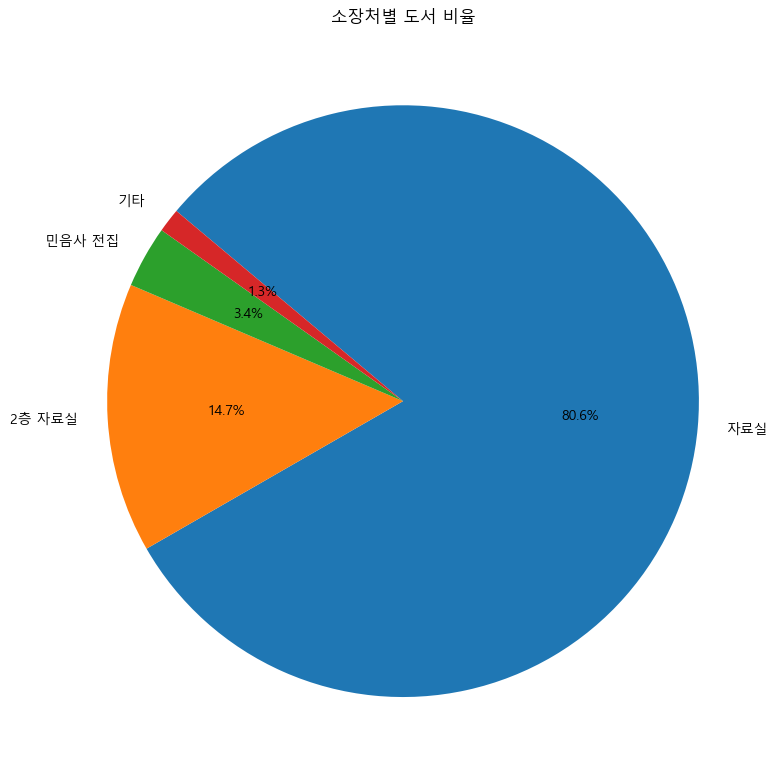

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 데이터 로드 (파일 경로는 너가 가진 csv 파일로 수정해줘)
df = pd.read_csv("상산고 도서관 소장자료 목록.csv")

# '소장처' 열의 개수 및 비율 계산
holding_counts = df['소장처'].value_counts()
holding_percentages = df['소장처'].value_counts(normalize=True) * 100

# 5% 미만인 항목들을 '기타'로 묶기
threshold = 1
small_categories = holding_percentages[holding_percentages < threshold].index
df['소장처'] = df['소장처'].replace(small_categories, '기타')

# 다시 계산
holding_counts = df['소장처'].value_counts()
holding_percentages = df['소장처'].value_counts(normalize=True) * 100

# DataFrame으로 정리
holding_summary = pd.DataFrame({
    '개수': holding_counts,
    '비율(%)': holding_percentages.round(2)
})


plt.rc('font', family='Malgun Gothic')

plt.rcParams['axes.unicode_minus'] = False


# 🎨 원형 차트 시각화
plt.figure(figsize=(8, 8))
plt.pie(
    holding_summary['개수'],
    labels=holding_summary.index,
    autopct='%1.1f%%',
    startangle=140,
    counterclock=False
)
plt.title('소장처별 도서 비율')
plt.savefig('chart.png')

plt.tight_layout()

plt.show()

plt.close()


# PNG 파일로 저장


